In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors="coerce")
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()
df = df[
    (df["Restaurant_latitude"] != 0.0) &
    (df["Restaurant_longitude"] != 0.0) &
    (df["Delivery_location_latitude"] != 0.0) &
    (df["Delivery_location_longitude"] != 0.0) &
    (df["Type_of_vehicle"].isin(["scooter","motorcycle"])) 
]
df.dropna(inplace=True)

C:\Users\upeks\AppData\Local\Temp\ipykernel_10108\3398115205.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])


In [4]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45587,0x1178,RANCHIRES16DEL01,35,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,1900-01-01 21:45:00,21:55:00,conditions Windy,Jam,2,Drinks,motorcycle,1,No,Metropolitian,(min) 33
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,1900-01-01 23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [5]:
temp_df = df[["Restaurant_latitude", "Restaurant_longitude"]]
temp_df = temp_df.groupby(by=["Restaurant_latitude", "Restaurant_longitude"]).size().reset_index(name="Count")
temp_df.sort_values(by="Count", ascending=False, inplace=True)
temp_df = temp_df[
    (temp_df["Restaurant_latitude"].apply(lambda x: 26.0 <= x <= 27.0)) &
    (temp_df["Restaurant_longitude"].apply(lambda x: 75.0 <= x <= 76.0))
]

In [6]:
start_time = pd.to_datetime("00:01:01").time()
end_time = pd.to_datetime("23:59:59").time()
start_date = pd.to_datetime("2022-03-01")
end_date = pd.to_datetime("2022-04-06")
full_date_range = pd.date_range(start=start_date, end=end_date)
restaurant_latitude = temp_df["Restaurant_latitude"].mean()
restaurant_longitude = temp_df["Restaurant_longitude"].mean()

In [7]:
main_df = df[
    (df["Restaurant_latitude"].isin(temp_df["Restaurant_latitude"])) &
    (df["Restaurant_longitude"].isin(temp_df["Restaurant_longitude"])) &
    (df["Time_Orderd"].dt.time.between(start_time, end_time)) &
    (df["Order_Date"].between(start_date, end_date))
]
main_df["Restaurant_latitude"] = restaurant_latitude
main_df["Restaurant_longitude"] = restaurant_longitude

C:\Users\upeks\AppData\Local\Temp\ipykernel_10108\3327270742.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df["Restaurant_latitude"] = restaurant_latitude
C:\Users\upeks\AppData\Local\Temp\ipykernel_10108\3327270742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df["Restaurant_longitude"] = restaurant_longitude


In [8]:
scaler1 = StandardScaler()
main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude", "Delivery_location_longitude"]])

C:\Users\upeks\AppData\Local\Temp\ipykernel_10108\15163636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude", "Delivery_location_longitude"]])
C:\Users\upeks\AppData\Local\Temp\ipykernel_10108\15163636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude

In [9]:
def find_best_k(data, max_k):
    silhouette_scores = []
    kmeans_labels = []
    for k in range(2, max_k+1):
        kmeans_optimal = KMeans(n_clusters=k)
        kmeans_optimal.fit(data)
        kmeans_labels.append((k, kmeans_optimal.labels_))
        silhouette_scores.append((k, silhouette_score(data, kmeans_optimal.labels_)))
    return silhouette_scores, kmeans_labels

In [10]:
silhouette_scores, kmeans_labels = find_best_k(main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]], 10)
best_k, best_score = max(silhouette_scores, key=lambda x: x[1])
best_labels = next(lbl for k, lbl in kmeans_labels if k == best_k)
main_df["K-Means Label"] = best_labels

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

In [11]:
main_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Scaled_Customer_Latitude,Scaled_Customer_Longitude,K-Means Label
25,0x3231,JAPRES16DEL03,27,5,26.895981,75.794475,26.879596,75.830512,2022-04-05,1900-01-01 20:35:00,...,0,Snack,motorcycle,0,No,Urban,(min) 18,-1.536886,-0.740893,1
58,0xb002,JAPRES14DEL01,32,4.5,26.895981,75.794475,26.898420,75.810689,2022-03-26,1900-01-01 09:25:00,...,2,Buffet,scooter,0,No,NaN,(min) 20,-1.197347,-1.186158,1
60,0x8aa2,JAPRES18DEL02,25,4.8,26.895981,75.794475,26.993987,75.832891,2022-03-29,1900-01-01 22:25:00,...,1,Drinks,scooter,0,No,Urban,(min) 18,0.526447,-0.687455,1
84,0x156b,JAPRES03DEL02,30,5,26.895981,75.794475,26.933483,75.823139,2022-03-24,1900-01-01 11:45:00,...,1,Buffet,motorcycle,1,No,Metropolitian,(min) 31,-0.564897,-0.906505,1
119,0xadb4,JAPRES17DEL03,24,4.6,26.895981,75.794475,26.922313,75.836896,2022-04-03,1900-01-01 20:50:00,...,0,Drinks,motorcycle,0,No,Metropolitian,(min) 25,-0.766376,-0.597495,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45535,0x3781,JAPRES13DEL03,35,4.9,26.895981,75.794475,26.876156,75.832300,2022-03-09,1900-01-01 23:50:00,...,1,Snack,scooter,0,No,Urban,(min) 17,-1.598935,-0.700730,1
45539,0x1180,JAPRES04DEL02,24,5,26.895981,75.794475,26.952328,75.844257,2022-03-19,1900-01-01 20:50:00,...,1,Meal,scooter,1,No,Metropolitian,(min) 28,-0.224979,-0.432152,1
45540,0x988a,JAPRES19DEL02,28,4.3,26.895981,75.794475,26.933726,75.772820,2022-03-03,1900-01-01 08:30:00,...,0,Buffet,motorcycle,1,No,Urban,(min) 25,-0.560513,-2.036773,1
45561,0xb55b,JAPRES13DEL03,27,4,26.895981,75.794475,26.906156,75.862300,2022-03-15,1900-01-01 19:35:00,...,2,Meal,scooter,1,No,Metropolitian,(min) 31,-1.057809,-0.026869,1


C:\Users\upeks\AppData\Local\Temp\ipykernel_10108\3655206591.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


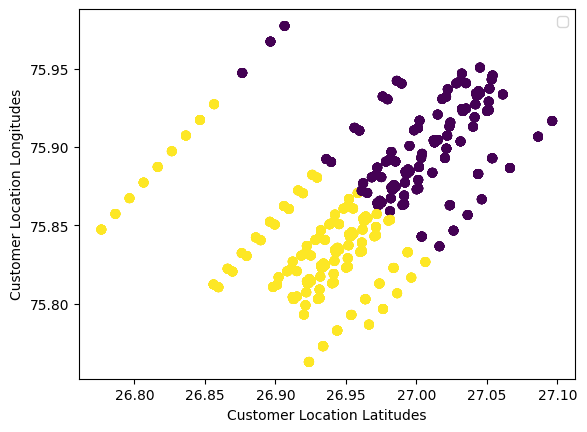

In [12]:
plt.scatter(x=main_df["Delivery_location_latitude"], y=main_df["Delivery_location_longitude"], c=main_df["K-Means Label"])
plt.xlabel("Customer Location Latitudes")
plt.ylabel("Customer Location Longitudes")
plt.legend()
plt.show()

In [13]:
cluster_df = main_df[main_df["K-Means Label"] == 1]
cluster_df.to_csv("cluster_df.csv")

In [14]:
cluster_df = main_df[main_df["K-Means Label"] == 1]
cluster_df = cluster_df.groupby(by="Order_Date").size().reset_index(name="Number of Deliveries")
cluster_df.sort_values(by="Order_Date", inplace=True)
cluster_df.set_index(keys="Order_Date", inplace=True)
cluster_df = cluster_df.reindex(labels=full_date_range, fill_value=0)
cluster_df.reset_index(inplace=True)
cluster_df.columns = ["Order_Date", "Number of Deliveries"]

In [15]:
data = cluster_df["Number of Deliveries"].to_numpy()

In [16]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        seq = data[i:i+sequence_length]
        lbl = data[i+sequence_length]
        sequences.append((seq, lbl))
    return sequences

In [17]:
sequences = create_sequences(data, 5)

In [18]:
X = np.array([seq[0] for seq in sequences])
y = np.array([[lbl[1]] for lbl in sequences])

In [19]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [20]:
X_train, X_next, y_train, y_next = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_next, y_next, test_size=0.5, shuffle=False)

In [21]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [22]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.initialize_weights()

    def initialize_weights(self):
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
            elif isinstance(layer, nn.LSTM):
                for name, param in layer.named_parameters():
                    if "weight" in name:
                        nn.init.xavier_uniform_(param.data)
                    elif "bias" in name:
                        nn.init.zeros_(param.data)
    
    def init_hidden(self, batch_size):
        return (
            torch.zeros(1, batch_size, self.hidden_size),
            torch.zeros(1, batch_size, self.hidden_size)
        )
    
    def forward(self, x):
        batch_size = x.size(0)
        hidden = self.init_hidden(batch_size)
        out, _ = self.lstm(x, hidden)
        output = self.fc(out[:, -1, :])
        return output
    

In [23]:
hidden_sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512]
learning_rates = np.logspace(-4, -1, 30, endpoint=True).tolist()
epochs_list = np.linspace(10, 500, 50).astype(int).tolist()

combinations = itertools.product(hidden_sizes, learning_rates, epochs_list) 

In [24]:
best_accuracy = float('inf')
best_params = (None, None, None)

In [25]:
for hidden_size, lr, epochs in combinations:
    if (hidden_size == 512) and (lr == 0.007278953843983146) and (epochs == 400):
        print(f"Training with hidden_size={hidden_size}, lr={lr}, epochs={epochs}")
        model = LSTMModel(1, hidden_size, 1)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        for epoch in range(epochs):         
            model.train()
            output = model(X_train.unsqueeze(-1))
            loss = criterion(output, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                val_output = model(X_val.unsqueeze(-1))
                val_loss = criterion(val_output, y_val)
            
            print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item()} - Val Loss: {val_loss.item()}")

        if val_loss.item() < best_accuracy:
            best_accuracy = val_loss.item()
            best_params = (hidden_size, lr, epochs)

        print(f"Best parameters: hidden_size={best_params[0]}, lr={best_params[1]}, epochs={best_params[2]} with loss={best_accuracy}")

Training with hidden_size=512, lr=0.007278953843983146, epochs=400
Epoch 1/400 - Loss: 0.3761477768421173 - Val Loss: 0.24818752706050873
Epoch 2/400 - Loss: 0.19406652450561523 - Val Loss: 0.22835862636566162
Epoch 3/400 - Loss: 0.29479852318763733 - Val Loss: 0.17864422500133514
Epoch 4/400 - Loss: 0.21633446216583252 - Val Loss: 0.13021497428417206
Epoch 5/400 - Loss: 0.14655530452728271 - Val Loss: 0.020657598972320557
Epoch 6/400 - Loss: 0.07258859276771545 - Val Loss: 0.12175150960683823
Epoch 7/400 - Loss: 0.3711845278739929 - Val Loss: 0.0976114273071289
Epoch 8/400 - Loss: 0.09088516980409622 - Val Loss: 0.26566776633262634
Epoch 9/400 - Loss: 0.19288432598114014 - Val Loss: 0.24805264174938202
Epoch 10/400 - Loss: 0.1933017373085022 - Val Loss: 0.20240040123462677
Epoch 11/400 - Loss: 0.17793621122837067 - Val Loss: 0.17800693213939667
Epoch 12/400 - Loss: 0.17131593823432922 - Val Loss: 0.1675095409154892
Epoch 13/400 - Loss: 0.16720238327980042 - Val Loss: 0.163677260279655

In [26]:
o_model = LSTMModel(1, best_params[0], 1)
o_optimizer = torch.optim.Adam(o_model.parameters(), lr=best_params[1])
o_criterion = nn.MSELoss()
o_epochs = best_params[2]

In [27]:
for epoch in range(o_epochs):
    o_model.train()
    o_output = o_model(X_train.unsqueeze(-1))
    o_loss = o_criterion(o_output, y_train)
    o_optimizer.zero_grad()
    o_loss.backward()
    o_optimizer.step()
    print(F"Epoch: {epoch+1} Loss: {o_loss.item()}")

Epoch: 1 Loss: 0.3735588788986206
Epoch: 2 Loss: 0.19441361725330353
Epoch: 3 Loss: 0.31369295716285706
Epoch: 4 Loss: 0.22342565655708313
Epoch: 5 Loss: 0.15817393362522125
Epoch: 6 Loss: 0.08128548413515091
Epoch: 7 Loss: 0.4005463421344757
Epoch: 8 Loss: 0.07593723386526108
Epoch: 9 Loss: 0.16740314662456512
Epoch: 10 Loss: 0.1890309453010559
Epoch: 11 Loss: 0.17724066972732544
Epoch: 12 Loss: 0.1697678416967392
Epoch: 13 Loss: 0.16662216186523438
Epoch: 14 Loss: 0.16275304555892944
Epoch: 15 Loss: 0.15844571590423584
Epoch: 16 Loss: 0.15625128149986267
Epoch: 17 Loss: 0.156951904296875
Epoch: 18 Loss: 0.15800067782402039
Epoch: 19 Loss: 0.15667875111103058
Epoch: 20 Loss: 0.15377458930015564
Epoch: 21 Loss: 0.15150482952594757
Epoch: 22 Loss: 0.1503572165966034
Epoch: 23 Loss: 0.1492575854063034
Epoch: 24 Loss: 0.14711007475852966
Epoch: 25 Loss: 0.14367540180683136
Epoch: 26 Loss: 0.1395428329706192
Epoch: 27 Loss: 0.13547903299331665
Epoch: 28 Loss: 0.13154754042625427
Epoch: 29 

In [28]:
o_model.eval()
with torch.no_grad():
    o_predictions = o_model(X_test.unsqueeze(-1))
    o_loss = o_criterion(o_predictions, y_test)
    print(f"Test Loss: {o_loss.item()}")

Test Loss: 0.06427744776010513


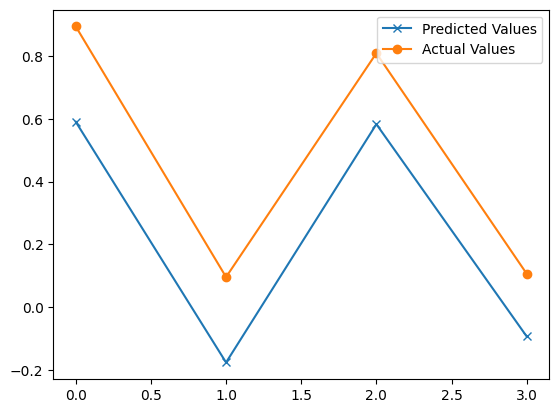

In [29]:
plt.plot(o_predictions.numpy(), label="Predicted Values", marker="x")
plt.plot(y_test.numpy(), label="Actual Values", marker="o")
plt.legend()
plt.show()

In [32]:
o_predictions_org = scaler_y.inverse_transform(o_predictions.numpy())
y_test_org = scaler_y.inverse_transform(y_test.numpy())

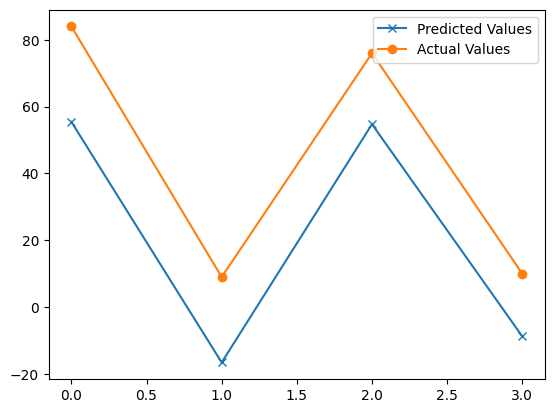

In [33]:
plt.plot(o_predictions_org, label="Predicted Values", marker="x")
plt.plot(y_test_org, label="Actual Values", marker="o")
plt.legend()
plt.show()